# Compare PyMC vs brms Model Results

This notebook compares the Bayesian hierarchical panel model results from:
- **PyMC** (`bayesian_model_py.md`) - Python implementation
- **brms** (`bayesian_model_r.Rmd`) - R implementation

Both models use the same:
- Data preprocessing (standardized predictors, centered target)
- Priors (Normal(0,1) for beta, Normal(0,5) for intercept, HalfNormal(1) for SDs)
- Model structure (random intercepts by country, shared slopes)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import scipy.stats as stats
from scipy.stats import pearsonr

from utils import (
    decorate, underride, configure_plot_style,
    log_and_print, set_log_file
)

configure_plot_style()

In [3]:
from utils import setup_beep_on_error
setup_beep_on_error()

## Setup Logging

In [4]:
# Setup logging and output directories
import os
os.makedirs('logs', exist_ok=True)
os.makedirs('../output/tables', exist_ok=True)
os.makedirs('../output/figs', exist_ok=True)

log_path = 'logs/compare_pymc_brms.txt'
log_file = open(log_path, 'w')
set_log_file(log_file)

log_and_print("="*80)
log_and_print("COMPARING PyMC vs brms MODEL RESULTS")
log_and_print("="*80)
log_and_print(f"Timestamp: {pd.Timestamp.now()}")
log_and_print("="*80)

COMPARING PyMC vs brms MODEL RESULTS
Timestamp: 2026-01-29 11:39:15.102741


## Load Results

### Load PyMC Results

In [5]:
# Load PyMC posterior samples
beta_pymc = pd.read_csv('../data/beta_samples_pymc.csv')
alpha_pymc = pd.read_csv('../data/alpha_samples_pymc.csv')
hyperparams_pymc = pd.read_csv('../data/hyperparams_pymc.csv')

# Load PyMC preprocessing parameters
with open('../data/preprocessing_params_pymc.json', 'r') as f:
    preprocessing_pymc = json.load(f)

log_and_print("\n" + "="*80)
log_and_print("PyMC RESULTS LOADED")
log_and_print("="*80)
log_and_print(f"Beta samples: {beta_pymc.shape[0]} draws × {beta_pymc.shape[1]} predictors")
log_and_print(f"Alpha samples: {alpha_pymc.shape[0]} draws × {alpha_pymc.shape[1]} countries")
log_and_print(f"Hyperparameters: {hyperparams_pymc.shape[0]} draws")
log_and_print(f"Predictors: {', '.join(beta_pymc.columns[:5])}... ({len(beta_pymc.columns)} total)")
log_and_print("="*80)


PyMC RESULTS LOADED
Beta samples: 4000 draws × 12 predictors
Alpha samples: 4000 draws × 37 countries
Hyperparameters: 4000 draws
Predictors: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular... (12 total)


### Load brms Results

In [6]:
# Load brms posterior samples
beta_brms = pd.read_csv('../data/beta_samples_brms.csv')
alpha_brms = pd.read_csv('../data/alpha_samples_brms.csv')
hyperparams_brms = pd.read_csv('../data/hyperparams_brms.csv')

# Load brms preprocessing parameters
with open('../data/preprocessing_params_brms.json', 'r') as f:
    preprocessing_brms = json.load(f)

log_and_print("\n" + "="*80)
log_and_print("brms RESULTS LOADED")
log_and_print("="*80)
log_and_print(f"Beta samples: {beta_brms.shape[0]} draws × {beta_brms.shape[1]} predictors")
log_and_print(f"Alpha samples: {alpha_brms.shape[0]} draws × {alpha_brms.shape[1]} countries")
log_and_print(f"Hyperparameters: {hyperparams_brms.shape[0]} draws")
log_and_print(f"Predictors: {', '.join(beta_brms.columns[:5])}... ({len(beta_brms.columns)} total)")
log_and_print("="*80)


brms RESULTS LOADED
Beta samples: 4000 draws × 12 predictors
Alpha samples: 4000 draws × 37 countries
Hyperparameters: 4000 draws
Predictors: Gap_Alcohol, Gap_Suicide, Gap_Homicide, Gap_RoadTraffic, Gap_Cardiovascular... (12 total)


### Verify Data Compatibility

In [7]:
# Check that predictors match
pymc_predictors = set(beta_pymc.columns)
brms_predictors = set(beta_brms.columns)

if pymc_predictors == brms_predictors:
    log_and_print("\n✓ Predictors match between PyMC and brms")
    predictors = sorted(list(pymc_predictors))
else:
    log_and_print("\n⚠ Predictor mismatch!")
    log_and_print(f"  PyMC only: {pymc_predictors - brms_predictors}")
    log_and_print(f"  brms only: {brms_predictors - pymc_predictors}")
    predictors = sorted(list(pymc_predictors & brms_predictors))
    log_and_print(f"  Common predictors: {len(predictors)}")

# Check country matching
pymc_countries = set(alpha_pymc.columns)
brms_countries = set(alpha_brms.columns)

if pymc_countries == brms_countries:
    log_and_print("✓ Countries match between PyMC and brms")
    countries = sorted(list(pymc_countries))
else:
    log_and_print("⚠ Country mismatch!")
    log_and_print(f"  PyMC only: {pymc_countries - brms_countries}")
    log_and_print(f"  brms only: {brms_countries - pymc_countries}")
    countries = sorted(list(pymc_countries & brms_countries))
    log_and_print(f"  Common countries: {len(countries)}")

# Align columns to match
beta_pymc_aligned = beta_pymc[predictors]
beta_brms_aligned = beta_brms[predictors]
alpha_pymc_aligned = alpha_pymc[countries]
alpha_brms_aligned = alpha_brms[countries]


✓ Predictors match between PyMC and brms
✓ Countries match between PyMC and brms


## Compare Preprocessing Parameters

In [8]:
log_and_print("\n" + "="*80)
log_and_print("PREPROCESSING PARAMETERS COMPARISON")
log_and_print("="*80)

# Helper function to extract float value (handles both float and list)
def get_float_value(value):
    """Extract float from value, handling both float and list types."""
    if isinstance(value, list):
        return float(value[0])
    return float(value)

# Compare standardization parameters
log_and_print("\nPredictor Standardization (X_mean):")
for pred in predictors[:5]:  # Show first 5
    pymc_mean = get_float_value(preprocessing_pymc['X_mean'][pred])
    brms_mean = get_float_value(preprocessing_brms['X_mean'][pred])
    diff = abs(pymc_mean - brms_mean)
    log_and_print(f"  {pred}: PyMC={pymc_mean:.6f}, brms={brms_mean:.6f}, diff={diff:.6f}")
    if diff > 1e-6:
        log_and_print(f"    ⚠ Warning: Difference > 1e-6")

log_and_print("\nPredictor Standardization (X_std):")
for pred in predictors[:5]:  # Show first 5
    pymc_std = get_float_value(preprocessing_pymc['X_std'][pred])
    brms_std = get_float_value(preprocessing_brms['X_std'][pred])
    diff = abs(pymc_std - brms_std)
    log_and_print(f"  {pred}: PyMC={pymc_std:.6f}, brms={brms_std:.6f}, diff={diff:.6f}")
    if diff > 1e-6:
        log_and_print(f"    ⚠ Warning: Difference > 1e-6")

# Compare target centering
pymc_y_mean = get_float_value(preprocessing_pymc['y_mean'])
brms_y_mean = get_float_value(preprocessing_brms['y_mean'])
y_mean_diff = abs(pymc_y_mean - brms_y_mean)
log_and_print(f"\nTarget Centering (y_mean):")
log_and_print(f"  PyMC: {pymc_y_mean:.6f}")
log_and_print(f"  brms: {brms_y_mean:.6f}")
log_and_print(f"  Difference: {y_mean_diff:.6f}")
if y_mean_diff > 1e-6:
    log_and_print(f"  ⚠ Warning: Difference > 1e-6")

# Compare sampling parameters
log_and_print(f"\nSampling Parameters:")
log_and_print(f"  PyMC: {preprocessing_pymc['sampling_params']}")
log_and_print(f"  brms: {preprocessing_brms['sampling_params']}")
log_and_print("="*80)


PREPROCESSING PARAMETERS COMPARISON

Predictor Standardization (X_mean):
  Gap_Alcohol: PyMC=6.207118, brms=6.207100, diff=0.000018
    ⚠ Warning: Difference > 1e-6
  Gap_COVID: PyMC=1.968277, brms=1.968300, diff=0.000023
    ⚠ Warning: Difference > 1e-6
  Gap_Cardiovascular: PyMC=-26.887347, brms=-26.887300, diff=0.000047
    ⚠ Warning: Difference > 1e-6
  Gap_ChronicRespiratory: PyMC=10.276800, brms=10.276800, diff=0.000000
  Gap_Diabetes: PyMC=-1.650104, brms=-1.650100, diff=0.000004
    ⚠ Warning: Difference > 1e-6

Predictor Standardization (X_std):
  Gap_Alcohol: PyMC=6.213521, brms=6.213500, diff=0.000021
    ⚠ Warning: Difference > 1e-6
  Gap_COVID: PyMC=10.602437, brms=10.602400, diff=0.000037
    ⚠ Warning: Difference > 1e-6
  Gap_Cardiovascular: PyMC=36.911076, brms=36.911100, diff=0.000024
    ⚠ Warning: Difference > 1e-6
  Gap_ChronicRespiratory: PyMC=10.728693, brms=10.728700, diff=0.000007
    ⚠ Warning: Difference > 1e-6
  Gap_Diabetes: PyMC=3.532463, brms=3.532500, di

## Compare Beta Coefficients (Predictor Effects)

In [9]:
log_and_print("\n" + "="*80)
log_and_print("BETA COEFFICIENTS COMPARISON")
log_and_print("="*80)

# Compute posterior means and credible intervals
beta_comparison = pd.DataFrame({
    'predictor': predictors,
    'pymc_mean': beta_pymc_aligned.mean().values,
    'brms_mean': beta_brms_aligned.mean().values,
    'pymc_q2.5': beta_pymc_aligned.quantile(0.025).values,
    'pymc_q97.5': beta_pymc_aligned.quantile(0.975).values,
    'brms_q2.5': beta_brms_aligned.quantile(0.025).values,
    'brms_q97.5': beta_brms_aligned.quantile(0.975).values,
})

# Compute differences
beta_comparison['mean_diff'] = beta_comparison['pymc_mean'] - beta_comparison['brms_mean']
beta_comparison['mean_diff_pct'] = 100 * beta_comparison['mean_diff'] / beta_comparison['pymc_mean'].abs()
beta_comparison['mean_diff_pct'] = beta_comparison['mean_diff_pct'].replace([np.inf, -np.inf], np.nan)

# Sort by absolute mean difference (create abs column for sorting)
beta_comparison['abs_mean_diff'] = beta_comparison['mean_diff'].abs()
beta_comparison = beta_comparison.sort_values('abs_mean_diff', ascending=False)

log_and_print("\nPosterior Mean Comparison (sorted by absolute difference):")
log_and_print(beta_comparison[['predictor', 'pymc_mean', 'brms_mean', 'mean_diff']].to_string(index=False))

# Overall correlation
corr_mean, pval_mean = pearsonr(beta_comparison['pymc_mean'], beta_comparison['brms_mean'])
log_and_print(f"\nCorrelation of posterior means: r = {corr_mean:.6f} (p = {pval_mean:.2e})")

# Maximum difference
max_diff_idx = beta_comparison['mean_diff'].abs().idxmax()
max_diff = beta_comparison.loc[max_diff_idx]
log_and_print(f"\nLargest difference:")
log_and_print(f"  Predictor: {max_diff['predictor']}")
log_and_print(f"  PyMC mean: {max_diff['pymc_mean']:.6f}")
log_and_print(f"  brms mean: {max_diff['brms_mean']:.6f}")
log_and_print(f"  Difference: {max_diff['mean_diff']:.6f} ({max_diff['mean_diff_pct']:.2f}%)")

log_and_print("="*80)


BETA COEFFICIENTS COMPARISON

Posterior Mean Comparison (sorted by absolute difference):
              predictor  pymc_mean  brms_mean  mean_diff
          Gap_Neoplasms   0.312061   0.313641  -0.001580
 Gap_ChronicRespiratory   0.297949   0.296483   0.001465
Gap_UnintentionalInjury   0.160387   0.161027  -0.000640
           Gap_Diabetes  -0.105591  -0.106159   0.000568
       Gap_LiverDisease   0.249536   0.249966  -0.000430
     Gap_Cardiovascular  -0.188036  -0.187689  -0.000346
            Gap_Suicide   0.365297   0.364961   0.000336
            Gap_Alcohol   0.138118   0.137795   0.000323
        Gap_RoadTraffic   0.446009   0.445741   0.000268
              Gap_COVID   0.108271   0.108079   0.000192
       Gap_DrugDisorder   0.091113   0.090987   0.000126
           Gap_Homicide   0.440568   0.440529   0.000039

Correlation of posterior means: r = 0.999993 (p = 1.18e-25)

Largest difference:
  Predictor: Gap_Neoplasms
  PyMC mean: 0.312061
  brms mean: 0.313641
  Difference: -0

### Visualize Beta Comparison

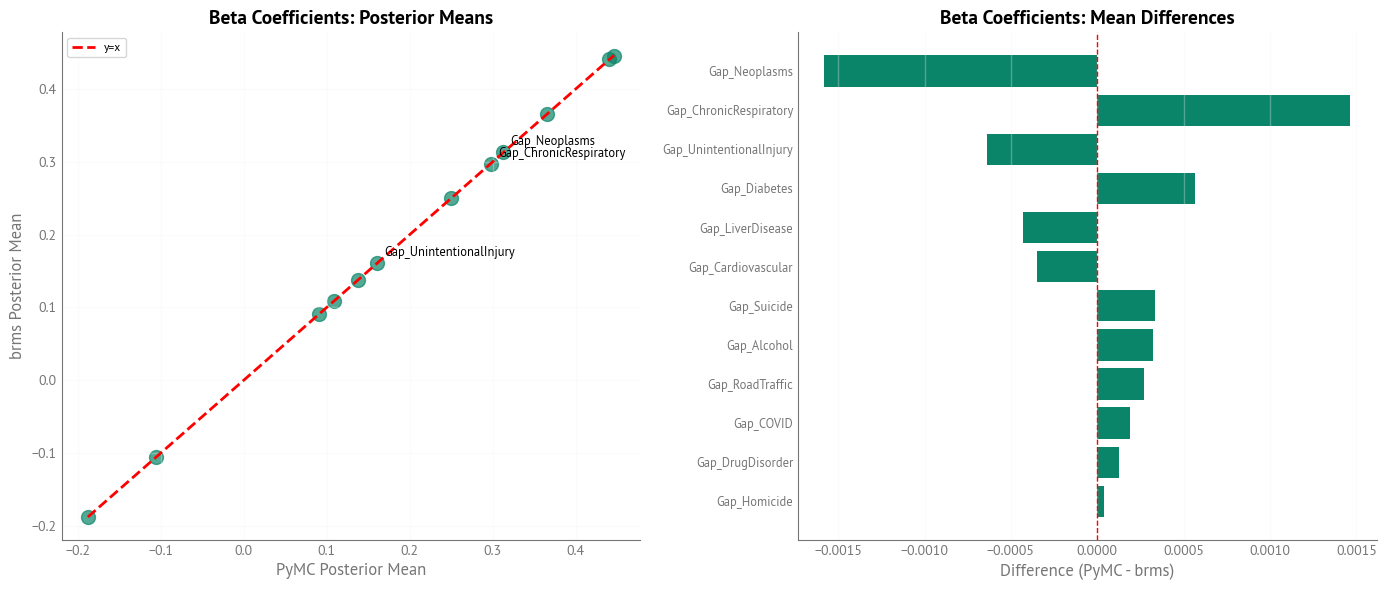


✓ Saved: ../output/figs/beta_comparison_pymc_brms.png


In [10]:
# Plot: Posterior means comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: PyMC vs brms means
ax = axes[0]
ax.scatter(beta_comparison['pymc_mean'], beta_comparison['brms_mean'], alpha=0.7, s=100)
ax.plot([beta_comparison['pymc_mean'].min(), beta_comparison['pymc_mean'].max()],
        [beta_comparison['pymc_mean'].min(), beta_comparison['pymc_mean'].max()],
        'r--', linewidth=2, label='y=x')
ax.set_xlabel('PyMC Posterior Mean', fontsize=12)
ax.set_ylabel('brms Posterior Mean', fontsize=12)
ax.set_title('Beta Coefficients: Posterior Means', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add predictor labels for largest differences
# Sort by absolute difference and get top 3
beta_comparison_abs = beta_comparison.copy()
beta_comparison_abs['abs_mean_diff'] = beta_comparison_abs['mean_diff'].abs()
top_diff = beta_comparison_abs.nlargest(3, 'abs_mean_diff')
for _, row in top_diff.iterrows():
    ax.annotate(row['predictor'], 
                (row['pymc_mean'], row['brms_mean']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Bar plot: Differences
ax = axes[1]
beta_comparison_sorted = beta_comparison.sort_values('abs_mean_diff')
ax.barh(range(len(beta_comparison_sorted)), beta_comparison_sorted['mean_diff'].values)
ax.set_yticks(range(len(beta_comparison_sorted)))
ax.set_yticklabels(beta_comparison_sorted['predictor'], fontsize=9)
ax.set_xlabel('Difference (PyMC - brms)', fontsize=12)
ax.set_title('Beta Coefficients: Mean Differences', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='r', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../output/figs/beta_comparison_pymc_brms.png', dpi=300, bbox_inches='tight')
plt.show()

log_and_print("\n✓ Saved: ../output/figs/beta_comparison_pymc_brms.png")

## Compare Alpha Coefficients (Country Intercepts)

In [11]:
log_and_print("\n" + "="*80)
log_and_print("ALPHA COEFFICIENTS (COUNTRY INTERCEPTS) COMPARISON")
log_and_print("="*80)

# Compute posterior means
alpha_comparison = pd.DataFrame({
    'country': countries,
    'pymc_mean': alpha_pymc_aligned.mean().values,
    'brms_mean': alpha_brms_aligned.mean().values,
})

alpha_comparison['mean_diff'] = alpha_comparison['pymc_mean'] - alpha_comparison['brms_mean']
# Sort by absolute mean difference (create abs column for sorting)
alpha_comparison['abs_mean_diff'] = alpha_comparison['mean_diff'].abs()
alpha_comparison = alpha_comparison.sort_values('abs_mean_diff', ascending=False)

# Overall correlation
corr_alpha, pval_alpha = pearsonr(alpha_comparison['pymc_mean'], alpha_comparison['brms_mean'])
log_and_print(f"\nCorrelation of posterior means: r = {corr_alpha:.6f} (p = {pval_alpha:.2e})")

# Maximum difference
max_diff_alpha_idx = alpha_comparison['mean_diff'].abs().idxmax()
max_diff_alpha = alpha_comparison.loc[max_diff_alpha_idx]
log_and_print(f"\nLargest difference:")
log_and_print(f"  Country: {max_diff_alpha['country']}")
log_and_print(f"  PyMC mean: {max_diff_alpha['pymc_mean']:.6f}")
log_and_print(f"  brms mean: {max_diff_alpha['brms_mean']:.6f}")
log_and_print(f"  Difference: {max_diff_alpha['mean_diff']:.6f}")

log_and_print("\nTop 10 differences:")
log_and_print(alpha_comparison.head(10)[['country', 'pymc_mean', 'brms_mean', 'mean_diff']].to_string(index=False))

log_and_print("="*80)


ALPHA COEFFICIENTS (COUNTRY INTERCEPTS) COMPARISON

Correlation of posterior means: r = 0.999997 (p = 9.95e-93)

Largest difference:
  Country: JPN
  PyMC mean: 0.638829
  brms mean: 0.634780
  Difference: 0.004049

Top 10 differences:
country  pymc_mean  brms_mean  mean_diff
    JPN   0.638829   0.634780   0.004049
    GRC  -0.161971  -0.165380   0.003409
    HUN  -0.192342  -0.195524   0.003183
    BEL  -0.836984  -0.833875  -0.003109
    LVA   1.271199   1.268123   0.003076
    FIN   0.472242   0.474816  -0.002574
    FRA   0.854605   0.852065   0.002540
    CHL  -0.468882  -0.470817   0.001935
    DNK   0.099313   0.097380   0.001933
    POL   0.780930   0.779228   0.001702


### Visualize Alpha Comparison

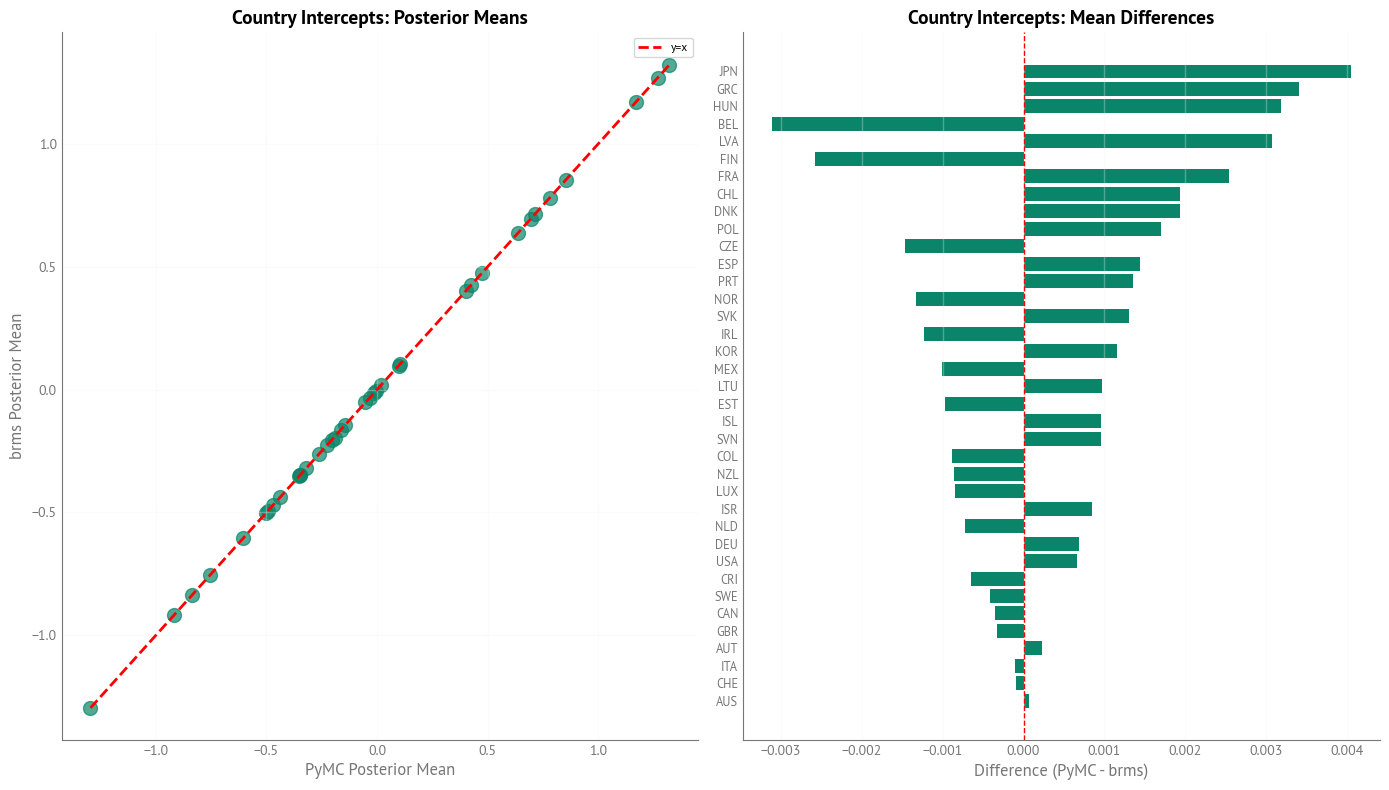


✓ Saved: ../output/figs/alpha_comparison_pymc_brms.png


In [12]:
# Plot: Country intercepts comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Scatter plot
ax = axes[0]
ax.scatter(alpha_comparison['pymc_mean'], alpha_comparison['brms_mean'], alpha=0.7, s=100)
ax.plot([alpha_comparison['pymc_mean'].min(), alpha_comparison['pymc_mean'].max()],
        [alpha_comparison['pymc_mean'].min(), alpha_comparison['pymc_mean'].max()],
        'r--', linewidth=2, label='y=x')
ax.set_xlabel('PyMC Posterior Mean', fontsize=12)
ax.set_ylabel('brms Posterior Mean', fontsize=12)
ax.set_title('Country Intercepts: Posterior Means', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Bar plot: Differences
ax = axes[1]
alpha_comparison_sorted = alpha_comparison.sort_values('abs_mean_diff')
ax.barh(range(len(alpha_comparison_sorted)), alpha_comparison_sorted['mean_diff'].values)
ax.set_yticks(range(len(alpha_comparison_sorted)))
ax.set_yticklabels(alpha_comparison_sorted['country'], fontsize=9)
ax.set_xlabel('Difference (PyMC - brms)', fontsize=12)
ax.set_title('Country Intercepts: Mean Differences', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='r', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../output/figs/alpha_comparison_pymc_brms.png', dpi=300, bbox_inches='tight')
plt.show()

log_and_print("\n✓ Saved: ../output/figs/alpha_comparison_pymc_brms.png")

## Compare Hyperparameters

In [13]:
log_and_print("\n" + "="*80)
log_and_print("HYPERPARAMETERS COMPARISON")
log_and_print("="*80)

# Compare each hyperparameter
for param in ['mu_alpha', 'sigma_alpha', 'sigma']:
    pymc_mean = hyperparams_pymc[param].mean()
    brms_mean = hyperparams_brms[param].mean()
    pymc_q2_5 = hyperparams_pymc[param].quantile(0.025)
    pymc_q97_5 = hyperparams_pymc[param].quantile(0.975)
    brms_q2_5 = hyperparams_brms[param].quantile(0.025)
    brms_q97_5 = hyperparams_brms[param].quantile(0.975)
    
    mean_diff = pymc_mean - brms_mean
    corr, pval = pearsonr(hyperparams_pymc[param], hyperparams_brms[param])
    
    log_and_print(f"\n{param}:")
    log_and_print(f"  PyMC: mean={pymc_mean:.6f}, 95%% CI=[{pymc_q2_5:.6f}, {pymc_q97_5:.6f}]")
    log_and_print(f"  brms: mean={brms_mean:.6f}, 95%% CI=[{brms_q2_5:.6f}, {brms_q97_5:.6f}]")
    log_and_print(f"  Difference: {mean_diff:.6f}")
    log_and_print(f"  Correlation: r={corr:.6f} (p={pval:.2e})")

log_and_print("="*80)


HYPERPARAMETERS COMPARISON

mu_alpha:
  PyMC: mean=-0.002220, 95%% CI=[-0.218355, 0.213219]
  brms: mean=0.000879, 95%% CI=[-0.203489, 0.206160]
  Difference: -0.003099
  Correlation: r=0.018567 (p=2.40e-01)

sigma_alpha:
  PyMC: mean=0.646637, 95%% CI=[0.498436, 0.846109]
  brms: mean=0.652230, 95%% CI=[0.500939, 0.843311]
  Difference: -0.005593
  Correlation: r=0.009848 (p=5.34e-01)

sigma:
  PyMC: mean=0.275380, 95%% CI=[0.263244, 0.288812]
  brms: mean=0.275458, 95%% CI=[0.262337, 0.289117]
  Difference: -0.000079
  Correlation: r=-0.009973 (p=5.28e-01)


### Visualize Hyperparameters Comparison

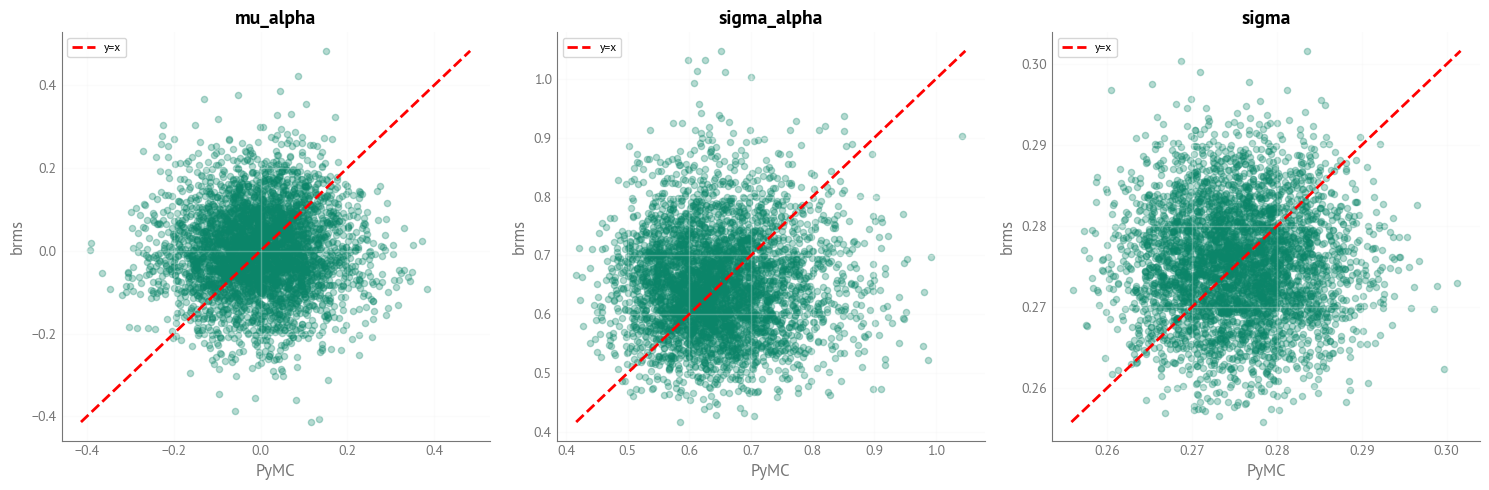


✓ Saved: ../output/figs/hyperparams_comparison_pymc_brms.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, param in enumerate(['mu_alpha', 'sigma_alpha', 'sigma']):
    ax = axes[idx]
    ax.scatter(hyperparams_pymc[param], hyperparams_brms[param], alpha=0.3, s=20)
    min_val = min(hyperparams_pymc[param].min(), hyperparams_brms[param].min())
    max_val = max(hyperparams_pymc[param].max(), hyperparams_brms[param].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
    ax.set_xlabel('PyMC', fontsize=12)
    ax.set_ylabel('brms', fontsize=12)
    ax.set_title(f'{param}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figs/hyperparams_comparison_pymc_brms.png', dpi=300, bbox_inches='tight')
plt.show()

log_and_print("\n✓ Saved: ../output/figs/hyperparams_comparison_pymc_brms.png")

## Summary Statistics

In [15]:
log_and_print("\n" + "="*80)
log_and_print("SUMMARY STATISTICS")
log_and_print("="*80)

# Beta coefficients
beta_corr_all = []
for pred in predictors:
    corr, _ = pearsonr(beta_pymc_aligned[pred], beta_brms_aligned[pred])
    beta_corr_all.append(corr)

log_and_print(f"\nBeta Coefficients:")
log_and_print(f"  Mean correlation: {np.mean(beta_corr_all):.6f}")
log_and_print(f"  Min correlation: {np.min(beta_corr_all):.6f}")
log_and_print(f"  Max correlation: {np.max(beta_corr_all):.6f}")

# Alpha coefficients
alpha_corr_all = []
for country in countries:
    corr, _ = pearsonr(alpha_pymc_aligned[country], alpha_brms_aligned[country])
    alpha_corr_all.append(corr)

log_and_print(f"\nAlpha Coefficients (Country Intercepts):")
log_and_print(f"  Mean correlation: {np.mean(alpha_corr_all):.6f}")
log_and_print(f"  Min correlation: {np.min(alpha_corr_all):.6f}")
log_and_print(f"  Max correlation: {np.max(alpha_corr_all):.6f}")

# Hyperparameters
hyperparams_corr = {}
for param in ['mu_alpha', 'sigma_alpha', 'sigma']:
    corr, _ = pearsonr(hyperparams_pymc[param], hyperparams_brms[param])
    hyperparams_corr[param] = corr

log_and_print(f"\nHyperparameters:")
for param, corr in hyperparams_corr.items():
    log_and_print(f"  {param}: r={corr:.6f}")

log_and_print("="*80)


SUMMARY STATISTICS

Beta Coefficients:
  Mean correlation: -0.007724
  Min correlation: -0.030118
  Max correlation: 0.016344

Alpha Coefficients (Country Intercepts):
  Mean correlation: 0.000915
  Min correlation: -0.032254
  Max correlation: 0.032426

Hyperparameters:
  mu_alpha: r=0.018567
  sigma_alpha: r=0.009848
  sigma: r=-0.009973


## Save Comparison Results

In [16]:
# Save comparison tables
beta_comparison.to_csv('../output/tables/beta_comparison_pymc_brms.csv', index=False)
alpha_comparison.to_csv('../output/tables/alpha_comparison_pymc_brms.csv', index=False)

log_and_print("\n✓ Saved comparison tables:")
log_and_print("  ../output/tables/beta_comparison_pymc_brms.csv")
log_and_print("  ../output/tables/alpha_comparison_pymc_brms.csv")


✓ Saved comparison tables:
  ../output/tables/beta_comparison_pymc_brms.csv
  ../output/tables/alpha_comparison_pymc_brms.csv


## Close Log File

In [17]:
log_and_print(f"\nLog file saved: {log_path}")
log_file.close()


Log file saved: logs/compare_pymc_brms.txt


In [18]:
from utils import beep
beep()